# 04 — Implementing a VAE (Variational Autoencoder) for Image Generation

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement the VAE architecture: encoder → (μ, log σ²) → reparameterized z → decoder
- Understand variational inference: the reparameterization trick and the ELBO loss
- **Generate images** by decoding samples from the latent prior
- Apply a VAE to a real task: anomaly detection by reconstruction error

## 🔗 Prerequisites

- ✅ Examples 01–03 (generative modeling, latent variables, log-likelihood)
- ✅ PyTorch training loops (Course 08)

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Implementing a VAE (Variational Autoencoder) for image generation

---

## Introduction

A **VAE** is the deep, continuous version of the latent-variable model from example 03: an **encoder** network maps each image to a Gaussian over latent space (mean μ and log-variance), a **decoder** network maps latent vectors back to images, and training maximizes the **ELBO** — reconstruction quality plus a KL term that keeps the latent space close to N(0, I) so we can generate by sampling z ~ N(0, I) and decoding.


In [1]:
# WHAT/WHY: import PyTorch and plotting — everything in this notebook is
# pure PyTorch + torchvision (MNIST), no external model downloads.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
print(f'PyTorch {torch.__version__}')


PyTorch 2.13.0


## Part 1 — Build and Train the VAE on MNIST

Three pieces to watch for in the code:

1. **Encoder** outputs *two* vectors per image: μ and log σ² — a full Gaussian per input, not a single point.
2. **Reparameterization trick**: `z = μ + σ·ε` with `ε ~ N(0,1)` — moves the randomness into ε so gradients can flow through μ and σ.
3. **ELBO loss** = reconstruction loss (binary cross-entropy per pixel) + KL divergence to N(0, I). The KL term is what makes the latent space *sampleable* afterwards.


Epoch 1/4 — avg ELBO loss per image: 246.94


Epoch 2/4 — avg ELBO loss per image: 174.00


Epoch 3/4 — avg ELBO loss per image: 151.33


Epoch 4/4 — avg ELBO loss per image: 139.61


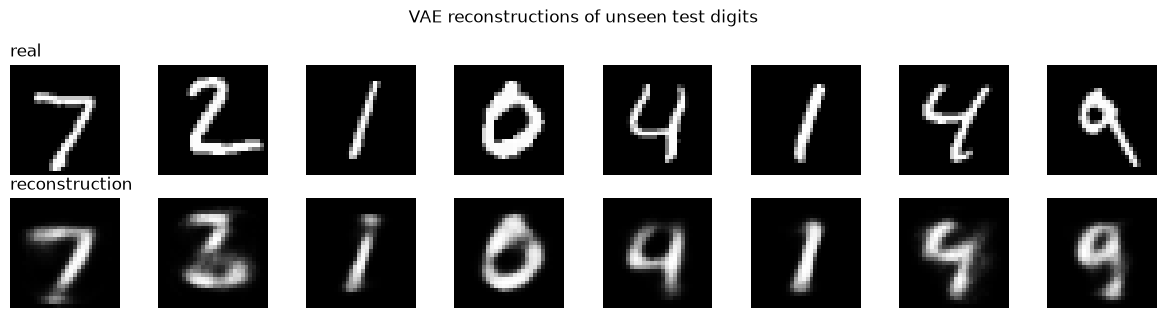

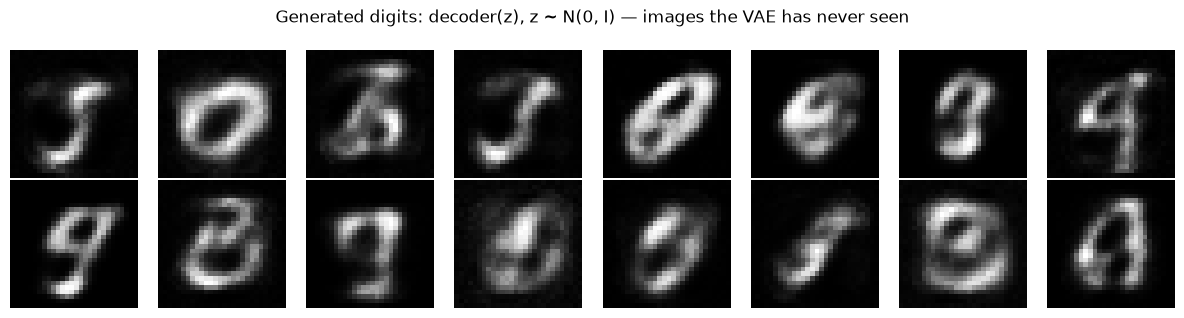

Generation recipe: sample z from the prior, decode. The KL term in the
loss is what made the prior a valid place to sample from.


In [2]:
# WHAT/WHY: train a small VAE on real MNIST digits, then show the three
# outputs that matter: (a) reconstructions of real digits, (b) brand-new
# digits generated by decoding z ~ N(0, I) — the "image generation" this
# notebook promises — and (c) the training loss falling.
torch.manual_seed(42)
LATENT = 16          # size of the latent vector z
EPOCHS = 4
BATCH  = 128

# ── Data: a 12,800-image MNIST subset keeps CPU training fast ─────────────
dataset = torchvision.datasets.MNIST('./data/mnist', train=True, download=True,
                                     transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── VAE: encoder → (mu, logvar) → reparameterized z → decoder ─────────────
class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)      # head 1: mean of q(z|x)
        self.logvar = nn.Linear(256, z)      # head 2: log-variance of q(z|x)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps — randomness lives in eps, gradients flow to mu/sigma
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE()
opt = optim.Adam(vae.parameters(), lr=1e-3)

# ── Training loop: ELBO = reconstruction BCE + KL(q(z|x) || N(0, I)) ──────
for epoch in range(EPOCHS):
    total = 0.0
    for x, _ in loader:
        recon, mu, logvar = vae(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (recon_loss + kl_loss) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} — avg ELBO loss per image: {total/len(loader):.2f}")

# ── (a) Reconstructions: top row = real digits, bottom row = VAE output ───
vae.eval()
test_ds = torchvision.datasets.MNIST('./data/mnist', train=False, transform=T.ToTensor())
x_test  = torch.stack([test_ds[i][0] for i in range(8)])
with torch.no_grad():
    recon, _, _ = vae(x_test)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray');  axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(),  cmap='gray');  axes[1, i].axis('off')
axes[0, 0].set_title("real", loc='left'); axes[1, 0].set_title("reconstruction", loc='left')
plt.suptitle("VAE reconstructions of unseen test digits")
plt.tight_layout(); plt.show()

# ── (b) GENERATION: decode z ~ N(0, I) — brand-new digits from noise ──────
with torch.no_grad():
    z_prior   = torch.randn(16, LATENT)       # sample the prior
    generated = vae.decode(z_prior)           # decode → new images

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("Generated digits: decoder(z), z ~ N(0, I) — images the VAE has never seen")
plt.tight_layout(); plt.show()

print("Generation recipe: sample z from the prior, decode. The KL term in the")
print("loss is what made the prior a valid place to sample from.")


## Part 2 — 🌍 Real-World Worked Example: VAE Anomaly Detection on MNIST

**Industry context:**
- **Manufacturing:** VAE-style models flag defective parts on assembly lines
- **Finance:** payment providers score transactions by how badly they reconstruct
- **Healthcare:** anomalous medical scans reconstruct poorly under a model of normal scans

The idea: train the VAE **only on "normal" data** (here: the digit 0). Anything it has never seen (here: the digit 1) reconstructs badly — high reconstruction error = anomaly flag.


Training VAE on class 0 only (5 epochs)...
  Epoch 1/5 — loss=285.06


  Epoch 2/5 — loss=185.87
  Epoch 3/5 — loss=165.22


  Epoch 4/5 — loss=153.97
  Epoch 5/5 — loss=145.63

Anomaly detection results:
  Normal (class 0) avg error:  0.1547
  Anomaly (class 1) avg error: 0.2996
  Anomaly detection rate: 100%
  (Threshold = 90th percentile of normal errors: 0.1944)


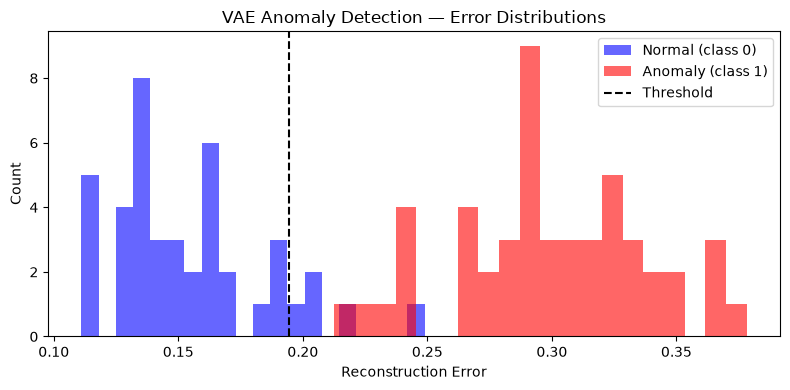

In [3]:
# WHAT/WHY: train a VAE only on digit 0, then score unseen digits by
# reconstruction error — 0s reconstruct well (low error), 1s reconstruct badly
# (high error). Thresholding that error is a production anomaly-detection
# pattern. The histogram at the end shows the two error distributions.
torch.manual_seed(42)
BATCH = 128

train_ds = torchvision.datasets.MNIST('./data/mnist', train=True,  download=True, transform=T.ToTensor())
test_ds  = torchvision.datasets.MNIST('./data/mnist', train=False, download=True, transform=T.ToTensor())

# ── "Normal" training set: class 0 only ───────────────────────────────────
train_0 = torch.utils.data.Subset(train_ds, [i for i in range(len(train_ds)) if train_ds[i][1] == 0])
loader  = torch.utils.data.DataLoader(train_0, batch_size=BATCH, shuffle=True)

# ── Fresh VAE (same architecture as Part 1) trained on 0s only ────────────
model = VAE()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training VAE on class 0 only (5 epochs)...")
for epoch in range(5):
    total = 0.0
    for i, (x, _) in enumerate(loader):
        recon, mu, logvar = model(x)
        bce = F.binary_cross_entropy(recon, x, reduction='sum')
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (bce + kld) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"  Epoch {epoch+1}/5 — loss={total/(i+1):.2f}")

# ── Score unseen images by per-pixel reconstruction error ─────────────────
model.eval()
def recon_errors(images):
    x = torch.stack(images)
    with torch.no_grad():
        r, mu, logvar = model(x)
    return F.binary_cross_entropy(r.view(len(x), -1), x.view(len(x), -1),
                                  reduction='none').mean(1).numpy()

normal_imgs  = [test_ds[i][0] for i in range(500) if test_ds[i][1] == 0][:50]  # seen class
anomaly_imgs = [test_ds[i][0] for i in range(500) if test_ds[i][1] == 1][:50]  # unseen class
normal_err   = recon_errors(normal_imgs)
anomaly_err  = recon_errors(anomaly_imgs)

# ── Threshold at the 90th percentile of normal errors, count detections ───
threshold    = np.percentile(normal_err, 90)
pct_detected = (anomaly_err > threshold).mean() * 100

print("\nAnomaly detection results:")
print(f"  Normal (class 0) avg error:  {normal_err.mean():.4f}")
print(f"  Anomaly (class 1) avg error: {anomaly_err.mean():.4f}")
print(f"  Anomaly detection rate: {pct_detected:.0f}%")
print(f"  (Threshold = 90th percentile of normal errors: {threshold:.4f})")

# ── Plot the two error distributions (shown inline) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_err,  bins=20, alpha=0.6, label='Normal (class 0)',  color='blue')
ax.hist(anomaly_err, bins=20, alpha=0.6, label='Anomaly (class 1)', color='red')
ax.axvline(threshold, color='black', linestyle='--', label='Threshold')
ax.set_xlabel("Reconstruction Error"); ax.set_ylabel("Count")
ax.set_title("VAE Anomaly Detection — Error Distributions")
ax.legend(); plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(the VAE paper)*
- Higgins et al. (2017) — [β-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)
- Doersch (2016) — [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908)

**State-of-the-Art:**
- Stable Diffusion runs its diffusion process inside a **VAE latent space** — the architecture you just built is a core component of modern text-to-image systems (diffusion itself is taught in Unit 3, example 04)


## 📝 Summary

In **04 — Implementing a VAE for Image Generation** you built the full VAE pipeline: encoder with μ/log σ² heads, the reparameterization trick, and the ELBO loss; you **generated new digit images by decoding samples from the prior** (see the "Generated digits" figure); and you applied the same model to anomaly detection, where the class the VAE never saw produced clearly higher reconstruction errors (compare the printed averages). Next: example 05 builds the other core architecture — the GAN.
